# Inżynieria uczenia maszynowego
## Lab1

### Dataset: Hotel Booking Demand
source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand


## 1. Dataset and packages download

In [59]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [60]:
import sys

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

if hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix):
    print("venv in use")
else:
    print("venv not in use")

packages_to_check = ['kagglehub', 'pandas', 'numpy', 'matplotlib', 'sklearn']
print("packages:")
for pkg in packages_to_check:
    try:
        if pkg == 'sklearn':
            __import__('sklearn')
            print(f"  ✓ scikit-learn")
        else:
            __import__(pkg)
            print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  ✗ {pkg} - is missing, do: pip install {pkg}")

Python executable: /home/szyjoz/Pulpit/mgr/inzynieria-uczenia-maszynowego/ium-project/.venv/bin/python
Python version: 3.14.3 (main, Feb 18 2026, 14:34:51) [GCC 15.2.1 20260209]
venv in use
packages:
  ✓ kagglehub
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ scikit-learn


In [61]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

print("packages loaded successfully")

packages loaded successfully


In [62]:
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
print("path:", path)
print("\nCatalog:")
print(os.listdir(path))

path: /home/szyjoz/.cache/kagglehub/datasets/jessemostipak/hotel-booking-demand/versions/1

Catalog:
['hotel_bookings.csv']


## 2. Data

In [63]:
hotel_data = pd.read_csv(os.path.join(path, 'hotel_bookings.csv'))

print("Data shape:", hotel_data.shape)
print("\nFirst 5 rows:")
print(hotel_data.head())

Data shape: (119390, 32)

First 5 rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                   

In [75]:
print("Column info:")
print(hotel_data.info())


Column info:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal          

In [76]:
print("Stats:")
print(hotel_data.describe(include='all'))

Stats:
             hotel    is_canceled      lead_time  arrival_date_year  \
count       119390  119390.000000  119390.000000      119390.000000   
unique           2            NaN            NaN                NaN   
top     City Hotel            NaN            NaN                NaN   
freq         79330            NaN            NaN                NaN   
mean           NaN       0.370416     104.011416        2016.156554   
std            NaN       0.482918     106.863097           0.707476   
min            NaN       0.000000       0.000000        2015.000000   
25%            NaN       0.000000      18.000000        2016.000000   
50%            NaN       0.000000      69.000000        2016.000000   
75%            NaN       1.000000     160.000000        2017.000000   
max            NaN       1.000000     737.000000        2017.000000   

       arrival_date_month  arrival_date_week_number  \
count              119390             119390.000000   
unique                 12     

## 3. Data cleaning

In [ ]:
print(f"Dataset size before cleaning: {hotel_data.shape}")

hotel_data = hotel_data.drop('company', axis=1, errors='ignore')
print(f"After removing 'company' column: {hotel_data.shape}")

hotel_data['agent'] = hotel_data['agent'].fillna(0)

hotel_data['children'] = hotel_data['children'].fillna(0)

hotel_data_clean = hotel_data.dropna(subset=['country'])

print(f"\nDataset size after cleaning: {hotel_data_clean.shape}")
print(f"Rows removed: {hotel_data.shape[0] - hotel_data_clean.shape[0]} ({(hotel_data.shape[0] - hotel_data_clean.shape[0])/hotel_data.shape[0]*100:.1f}%)")

Dataset size before cleaning: (119390, 32)
After removing 'company' column: (119390, 31)

Dataset size after cleaning: (118902, 31)
Rows removed: 488 (0.4%)


In [69]:
print("Distribution of target variable (is_canceled):")
print(hotel_data_clean['is_canceled'].value_counts())
print("\nPercentage distribution:")
print(hotel_data_clean['is_canceled'].value_counts(normalize=True) * 100)

Distribution of target variable (is_canceled):
is_canceled
0    74745
1    44157
Name: count, dtype: int64

Percentage distribution:
is_canceled
0    62.862694
1    37.137306
Name: proportion, dtype: float64


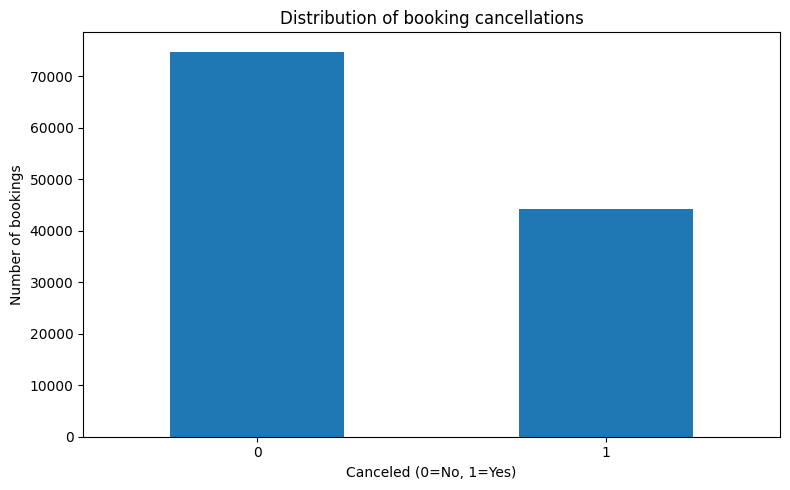

In [72]:
plt.figure(figsize=(8, 5))
hotel_data_clean['is_canceled'].value_counts().plot(kind='bar')
plt.title('Distribution of booking cancellations')
plt.xlabel('Canceled (0=No, 1=Yes)')
plt.ylabel('Number of bookings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Disison to train/dev/test

In [77]:
# Train 60%, Dev 20%, Test 20%

train_data, temp_data = train_test_split(
    hotel_data_clean,
    test_size=0.4,
    random_state=42,
    stratify=hotel_data_clean['is_canceled']
)

dev_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42,
    stratify=temp_data['is_canceled']
)

print(f"Train size: {train_data.shape[0]} ({train_data.shape[0]/hotel_data_clean.shape[0]*100:.1f}%)")
print(f"Dev size: {dev_data.shape[0]} ({dev_data.shape[0]/hotel_data_clean.shape[0]*100:.1f}%)")
print(f"Test size: {test_data.shape[0]} ({test_data.shape[0]/hotel_data_clean.shape[0]*100:.1f}%)")

Train size: 71341 (60.0%)
Dev size: 23780 (20.0%)
Test size: 23781 (20.0%)


In [78]:
print("\nClass distribution in Train set:")
print(train_data['is_canceled'].value_counts())
print(train_data['is_canceled'].value_counts(normalize=True) * 100)

print("\nClass distribution in Dev set:")
print(dev_data['is_canceled'].value_counts())
print(dev_data['is_canceled'].value_counts(normalize=True) * 100)

print("\nClass distribution in Test set:")
print(test_data['is_canceled'].value_counts())
print(test_data['is_canceled'].value_counts(normalize=True) * 100)


Class distribution in Train set:
is_canceled
0    44847
1    26494
Name: count, dtype: int64
is_canceled
0    62.86287
1    37.13713
Name: proportion, dtype: float64

Class distribution in Dev set:
is_canceled
0    14949
1     8831
Name: count, dtype: int64
is_canceled
0    62.863751
1    37.136249
Name: proportion, dtype: float64

Class distribution in Test set:
is_canceled
0    14949
1     8832
Name: count, dtype: int64
is_canceled
0    62.861108
1    37.138892
Name: proportion, dtype: float64


## 5. Statistics for each subset

In [80]:
def print_dataset_statistics(data, name):
    """Print dataset statistics"""
    print(f"\n{'='*60}")
    print(f"Statistics for set: {name}")
    print(f"{'='*60}")
    print(f"Number of rows: {data.shape[0]}")
    print(f"Number of columns: {data.shape[1]}")
    print(f"\nNumeric statistics:")
    print(data.describe().to_string())
    print(f"\nMissing values:")
    print(data.isnull().sum())

print_dataset_statistics(train_data, "TRAIN")
print_dataset_statistics(dev_data, "DEV")
print_dataset_statistics(test_data, "TEST")


Statistics for set: TRAIN
Number of rows: 71341
Number of columns: 31

Numeric statistics:
        is_canceled     lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights        adults      children        babies  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  booking_changes         agent  days_in_waiting_list           adr  required_car_parking_spaces  total_of_special_requests
count  71341.000000  71341.000000       71341.000000              71341.000000               71341.000000             71341.000000          71341.000000  71341.000000  71341.000000  71341.000000       71341.000000            71341.000000                    71341.000000     71341.000000  71341.000000          71341.000000  71341.000000                 71341.000000               71341.000000
mean       0.371371    104.175453        2016.154371                 27.136640                  15.790541                 

## 6. Data normalization

In [81]:
numeric_columns = train_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = train_data.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}):")
print(numeric_columns)
print(f"\nCategorical columns ({len(categorical_columns)}):")
print(categorical_columns)

Numeric columns (19):
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns (12):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


/tmp/ipykernel_16512/1681145114.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train_data.select_dtypes(include=['object']).columns.tolist()


In [82]:
from sklearn.preprocessing import MinMaxScaler

train_normalized = train_data.copy()
dev_normalized = dev_data.copy()
test_normalized = test_data.copy()

scaler = MinMaxScaler()

train_normalized[numeric_columns] = scaler.fit_transform(train_data[numeric_columns])

dev_normalized[numeric_columns] = scaler.transform(dev_data[numeric_columns])
test_normalized[numeric_columns] = scaler.transform(test_data[numeric_columns])

print("Numeric data normalization completed")
print(f"\nStatistics after normalization (Train):")
print(train_normalized[numeric_columns].describe())

Numeric data normalization completed

Statistics after normalization (Train):
        is_canceled     lead_time  arrival_date_year  \
count  71341.000000  71341.000000       71341.000000   
mean       0.371371      0.141351           0.577186   
std        0.483175      0.144889           0.353667   
min        0.000000      0.000000           0.000000   
25%        0.000000      0.024423           0.500000   
50%        0.000000      0.093623           0.500000   
75%        1.000000      0.218453           1.000000   
max        1.000000      1.000000           1.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count              71341.000000               71341.000000   
mean                   0.502628                   0.493018   
std                    0.261977                   0.292801   
min                    0.000000                   0.000000   
25%                    0.288462                   0.233333   
50%                    0.500000              

In [71]:
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    all_values = pd.concat([train_normalized[col], dev_normalized[col], test_normalized[col]])
    le.fit(all_values.astype(str).unique())
    label_encoders[col] = le
    
    train_normalized[col] = le.transform(train_normalized[col].astype(str))
    dev_normalized[col] = le.transform(dev_normalized[col].astype(str))
    test_normalized[col] = le.transform(test_normalized[col].astype(str))

print(f"\nVariables: {categorical_columns}")


Variables: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


## 7. Save processed data

In [83]:
output_dir = './prepared_data'
os.makedirs(output_dir, exist_ok=True)

train_normalized.to_csv(os.path.join(output_dir, 'hotel_booking_train.csv'), index=False)
dev_normalized.to_csv(os.path.join(output_dir, 'hotel_booking_dev.csv'), index=False)
test_normalized.to_csv(os.path.join(output_dir, 'hotel_booking_test.csv'), index=False)

print(f"Processed data has been saved to directory: {output_dir}")
print(f"  - hotel_booking_train.csv ({train_normalized.shape[0]} rows)")
print(f"  - hotel_booking_dev.csv ({dev_normalized.shape[0]} rows)")
print(f"  - hotel_booking_test.csv ({test_normalized.shape[0]} rows)")

Processed data has been saved to directory: ./prepared_data
  - hotel_booking_train.csv (71341 rows)
  - hotel_booking_dev.csv (23780 rows)
  - hotel_booking_test.csv (23781 rows)
